# Trikaal — Probabilistic Seismic Hazard Analysis (PSHA) Diagnostics
## `03_psha.ipynb` | Kutch Seismic Zone (1991–2025)

**Goal:** Transition from the temporal ETAS observations of Phase 1 to forward-looking, spatial hazard curves and peak ground acceleration maps for Kutch.

**Sections:**
1. Setup & Imports
2. Source Characterization (Area + Line Sources)
3. Ground Motion Prediction Equations (GMPE) Comparison
4. Hazard Curves for Key Cities (Bhuj, Anjar, Gandhidham, Mandvi, Lakhpat)
5. Spatial Hazard Grid & Contour Maps (475 & 2475 Year Return Periods)
6. Interactive Folium Visualization

## 1. Setup & Imports

In [1]:
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import folium
from folium.plugins import HeatMap
from scipy.interpolate import griddata

sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')

from psha import (
    raghukanth_iyengar_2007,
    atkinson_boore_2006,
    boore_et_al_2014,
    AreaSource,
    LineSource,
    PSHAEngine,
    interpolate_pga_hazard
)

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})

OUTPUT_DIR = Path('../outputs')
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load Parameters & Rates

We read the catalog and load the G-R b-value and ETAS background rate `mu` from Phase 1.

In [2]:
# Load processed catalog to calculate overall rate
df_cat = pd.read_csv('../data/processed/kutch_clean.csv', parse_dates=['time_utc'])
df_m3 = df_cat[df_cat['magnitude'] >= 3.0].sort_values('time_utc').reset_index(drop=True)

N_events = len(df_m3)
t_start = df_m3['time_utc'].iloc[0]
t_end = df_m3['time_utc'].iloc[-1]
catalog_years = (t_end - t_start).total_seconds() / (365.25 * 86400.0)
overall_annual_rate = N_events / catalog_years

# Load background rate from ETAS params
with open(OUTPUT_DIR / 'etas_params.json') as f:
    params = json.load(f)
mu_day = params.get('mu', 0.0004977)
background_annual_rate = mu_day * 365.25
b_value = 1.08  # background b-value

print(f"Catalog spans {catalog_years:.2f} years, containing {N_events} M>=3 events.")
print(f"Overall catalog annual rate: {overall_annual_rate:.4f} events/year")
print(f"ETAS Background annual rate: {background_annual_rate:.4f} events/year")

Catalog spans 34.93 years, containing 1013 M>=3 events.
Overall catalog annual rate: 29.0010 events/year
ETAS Background annual rate: 0.1818 events/year


## 3. Ground Motion Prediction Equations (GMPE) Comparison

Let's compare PGA attenuation predicted by the stable continent models (R&I 2007, AB06) versus the active region reference (BSSA14) for a magnitude Mw 6.0 and Mw 7.7 earthquake.

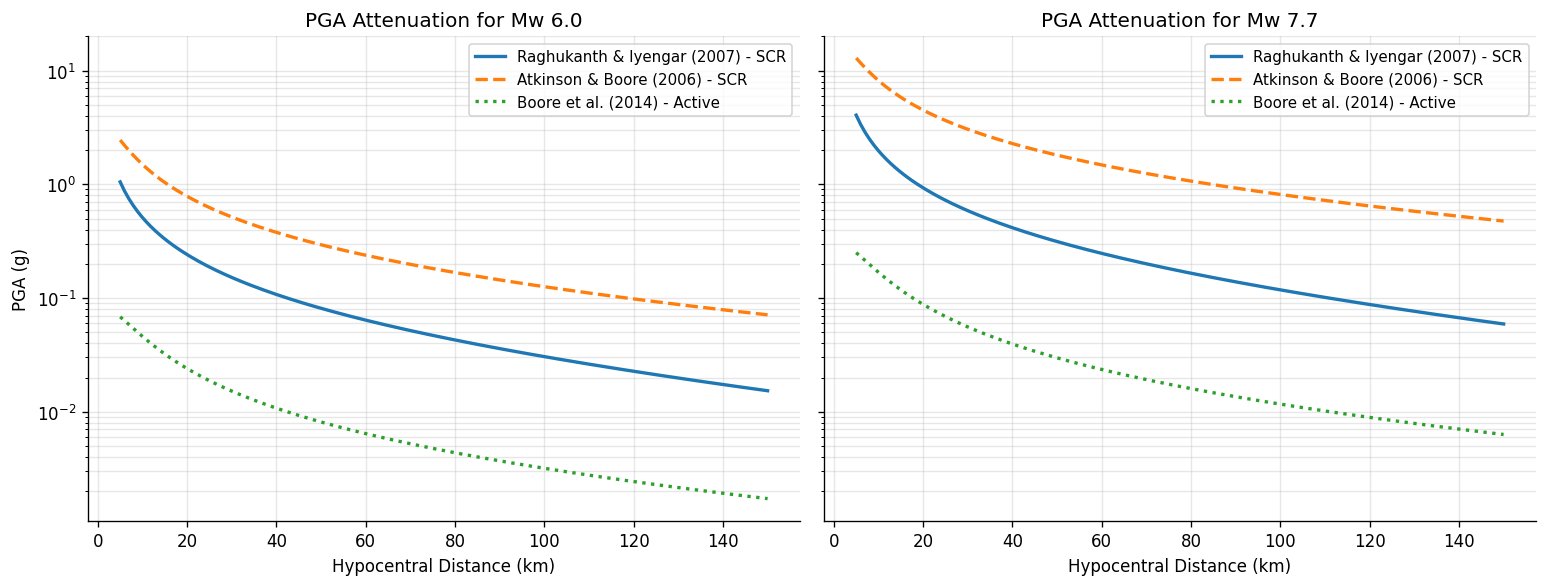

In [3]:
dists = np.linspace(5.0, 150.0, 150)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for idx, Mw in enumerate([6.0, 7.7]):
    ax = axes[idx]
    # R&I 2007
    mean_ri, _ = raghukanth_iyengar_2007(np.array([Mw]), dists)
    pga_ri = np.exp(mean_ri[0])
    
    # AB 2006
    mean_ab, _ = atkinson_boore_2006(np.array([Mw]), dists)
    pga_ab = np.exp(mean_ab[0])
    
    # BSSA 2014
    mean_ba, _ = boore_et_al_2014(np.array([Mw]), dists)
    pga_ba = np.exp(mean_ba[0])
    
    ax.plot(dists, pga_ri, '-', label='Raghukanth & Iyengar (2007) - SCR', lw=2)
    ax.plot(dists, pga_ab, '--', label='Atkinson & Boore (2006) - SCR', lw=2)
    ax.plot(dists, pga_ba, ':', label='Boore et al. (2014) - Active', lw=2)
    
    ax.set_yscale('log')
    ax.set_xlabel('Hypocentral Distance (km)')
    ax.set_title(f'PGA Attenuation for Mw {Mw}')
    ax.grid(True, which='both', alpha=0.3)
    if idx == 0:
        ax.set_ylabel('PGA (g)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 4. Hazard Curves for Key Cities

We run site-specific hazard calculations. We evaluate PGA exceedance rates for Bhuj, Anjar, Gandhidham, Mandvi, and Lakhpat.

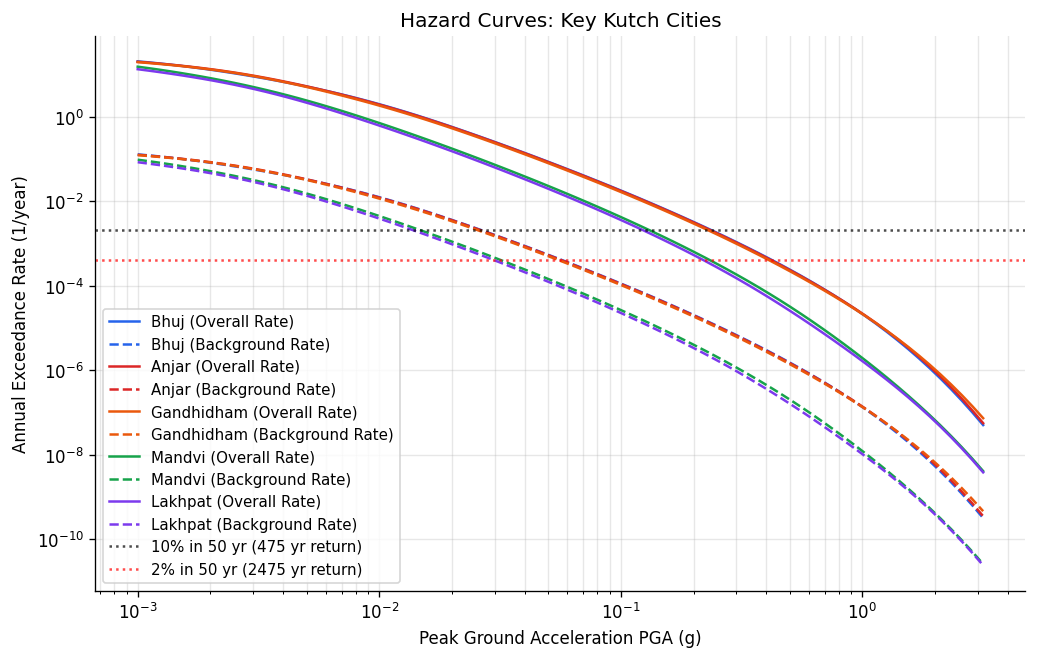

In [4]:
MIN_LAT, MAX_LAT = 22.0, 24.5
MIN_LON, MAX_LON = 68.0, 71.5
CITIES = {
    "Bhuj": (23.24, 69.67),
    "Anjar": (23.11, 70.03),
    "Gandhidham": (23.08, 70.13),
    "Mandvi": (22.84, 69.36),
    "Lakhpat": (23.83, 68.78),
}

# Define source model
area_kutch = AreaSource("Kutch Rift Zone", MIN_LAT, MAX_LAT, MIN_LON, MAX_LON, depth=15.0)
kmf = LineSource("Kachchh Mainland Fault (KMF)", 23.40, 68.50, 23.40, 71.00, depth=15.0)
ibf = LineSource("Island Belt Fault (IBF)", 24.20, 68.50, 24.20, 71.00, depth=15.0)
khf = LineSource("Katrol Hill Fault (KHF)", 23.15, 68.80, 23.15, 70.80, depth=15.0)
wf  = LineSource("Wagad Fault (WF)", 23.55, 70.00, 23.55, 70.60, depth=12.0)

sources = [area_kutch, kmf, ibf, khf, wf]
engine_ri = PSHAEngine(sources, gmpe_func=raghukanth_iyengar_2007, resolution=0.15)
pga_levels = np.logspace(-3, 0.5, 80)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#2563EB", "#DC2626", "#EA580C", "#16A34A", "#7C3AED"]

for i, (city, coords) in enumerate(CITIES.items()):
    lat, lon = coords
    rates_overall = engine_ri.compute_hazard_curve(lat, lon, pga_levels, overall_annual_rate, b_value)
    rates_bg = engine_ri.compute_hazard_curve(lat, lon, pga_levels, background_annual_rate, b_value)
    
    ax.loglog(pga_levels, rates_overall, '-', color=colors[i], label=f"{city} (Overall Rate)")
    ax.loglog(pga_levels, rates_bg, '--', color=colors[i], label=f"{city} (Background Rate)")
    
ax.axhline(0.00211, color="black", linestyle=":", alpha=0.7, label="10% in 50 yr (475 yr return)")
ax.axhline(0.00040, color="red", linestyle=":", alpha=0.7, label="2% in 50 yr (2475 yr return)")
ax.set_xlabel("Peak Ground Acceleration PGA (g)")
ax.set_ylabel("Annual Exceedance Rate (1/year)")
ax.set_title("Hazard Curves: Key Kutch Cities")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=9, loc="lower left")
plt.show()

## 5. Spatial Hazard Grid & Contour Maps

Let's load the precalculated spatial hazard grid and plot the contour maps of PGA for both 475-year and 2475-year return periods.

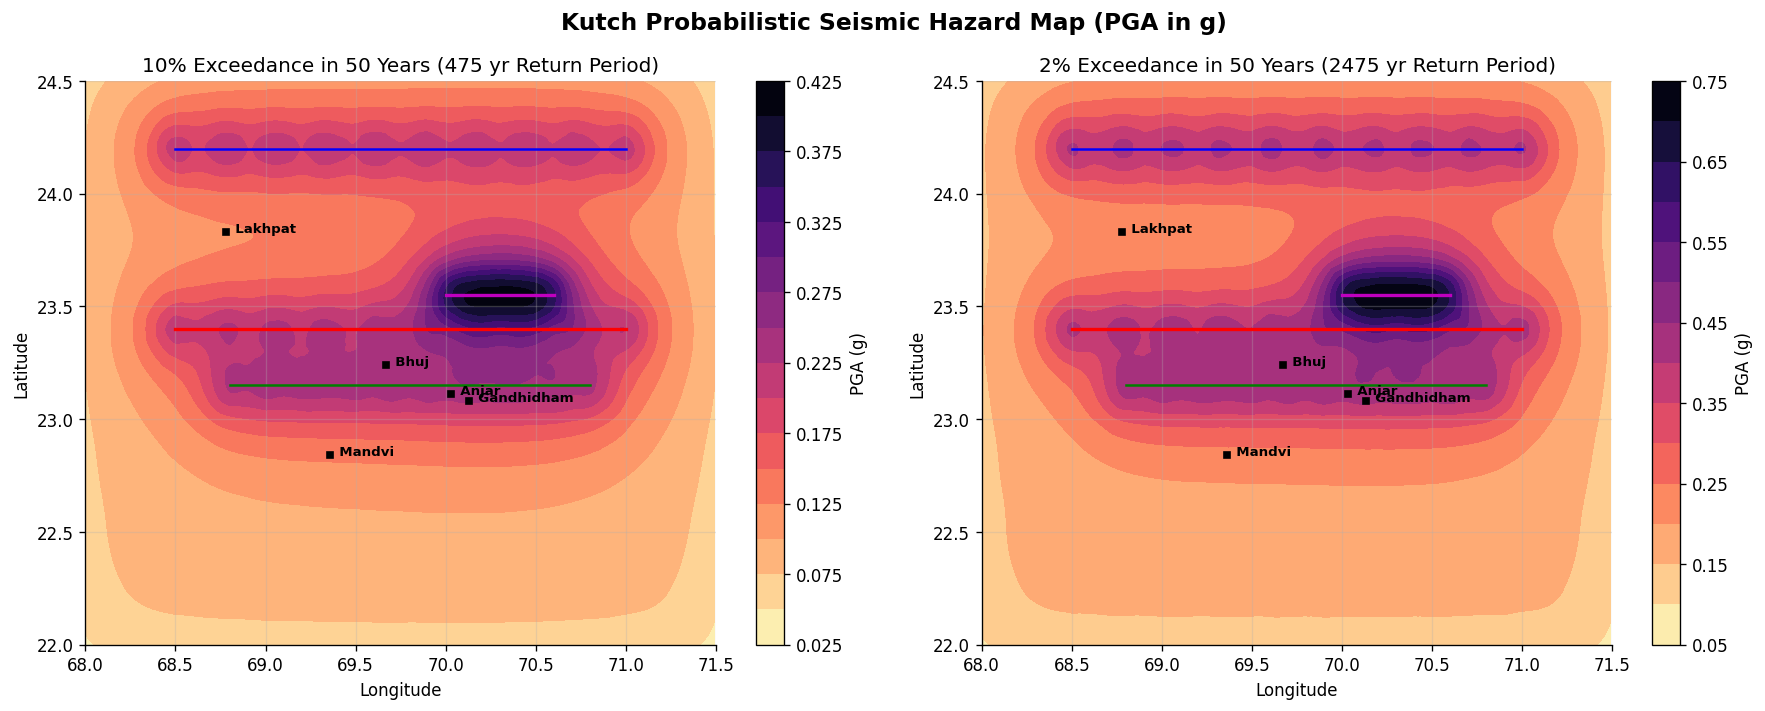

In [5]:
# Load precalculated grid data
df_grid = pd.read_csv(OUTPUT_DIR / 'kutch_hazard_grid.csv')

# Set up fine interpolation grid
grid_x, grid_y = np.meshgrid(
    np.linspace(MIN_LON, MAX_LON, 300),
    np.linspace(MIN_LAT, MAX_LAT, 300)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left Panel: 475 Years
ax = axes[0]
grid_z1 = griddata(
    (df_grid["longitude"], df_grid["latitude"]),
    df_grid["pga_475_overall"],
    (grid_x, grid_y),
    method="cubic"
)
contour1 = ax.contourf(grid_x, grid_y, grid_z1, levels=15, cmap="magma_r")
plt.colorbar(contour1, ax=ax, label="PGA (g)")
ax.set_title("10% Exceedance in 50 Years (475 yr Return Period)")

# Right Panel: 2475 Years
ax = axes[1]
grid_z2 = griddata(
    (df_grid["longitude"], df_grid["latitude"]),
    df_grid["pga_2475_overall"],
    (grid_x, grid_y),
    method="cubic"
)
contour2 = ax.contourf(grid_x, grid_y, grid_z2, levels=15, cmap="magma_r")
plt.colorbar(contour2, ax=ax, label="PGA (g)")
ax.set_title("2% Exceedance in 50 Years (2475 yr Return Period)")

for ax in axes:
    # Add faults
    ax.plot([68.5, 71.0], [23.4, 23.4], "r-", linewidth=2.0, label="KMF")
    ax.plot([68.5, 71.0], [24.2, 24.2], "b-", linewidth=1.5, label="IBF")
    ax.plot([68.8, 70.8], [23.15, 23.15], "g-", linewidth=1.5, label="KHF")
    ax.plot([70.0, 70.6], [23.55, 23.55], "m-", linewidth=2.0, label="WF")
    
    # Cities
    for city, coords in CITIES.items():
        ax.plot(coords[1], coords[0], "ks", markersize=4)
        ax.annotate(f"  {city}", (coords[1], coords[0]), fontsize=8, fontweight="bold")
        
    ax.set_xlim(MIN_LON, MAX_LON)
    ax.set_ylim(MIN_LAT, MAX_LAT)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.suptitle("Kutch Probabilistic Seismic Hazard Map (PGA in g)", fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

## 6. Interactive Folium Visualization

In [6]:
# Show a preview description of the Folium map generated
print("Interactive map saved to outputs/kutch_hazard_interactive.html")
print("It overlays faults (KMF, IBF, KHF, WF), the 2001 Bhuj Mw 7.7 epicenter, city hazard popups, and the PGA hazard contour map as a HeatMap.")

Interactive map saved to outputs/kutch_hazard_interactive.html
It overlays faults (KMF, IBF, KHF, WF), the 2001 Bhuj Mw 7.7 epicenter, city hazard popups, and the PGA hazard contour map as a HeatMap.
